In [3]:
import pandas as pd
import numpy as np

In [4]:
data_path = "../data/Heart_failure_clinical_records_dataset.csv"  
df = pd.read_csv(data_path)
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
# rename coloumns
df = df.rename(columns={
    'duration': 'time',
    'DEATH_EVENT': 'event'
})

In [11]:
# check renamed columns
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure',
       'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'event'],
      dtype='object')

In [13]:
# check event rate
df['event'].value_counts(normalize=True)

event
0    0.67893
1    0.32107
Name: proportion, dtype: float64

In [16]:
df.dtypes
df.describe() # get a sense of continuous variables and binary variables

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,event
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.837237,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.900919,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


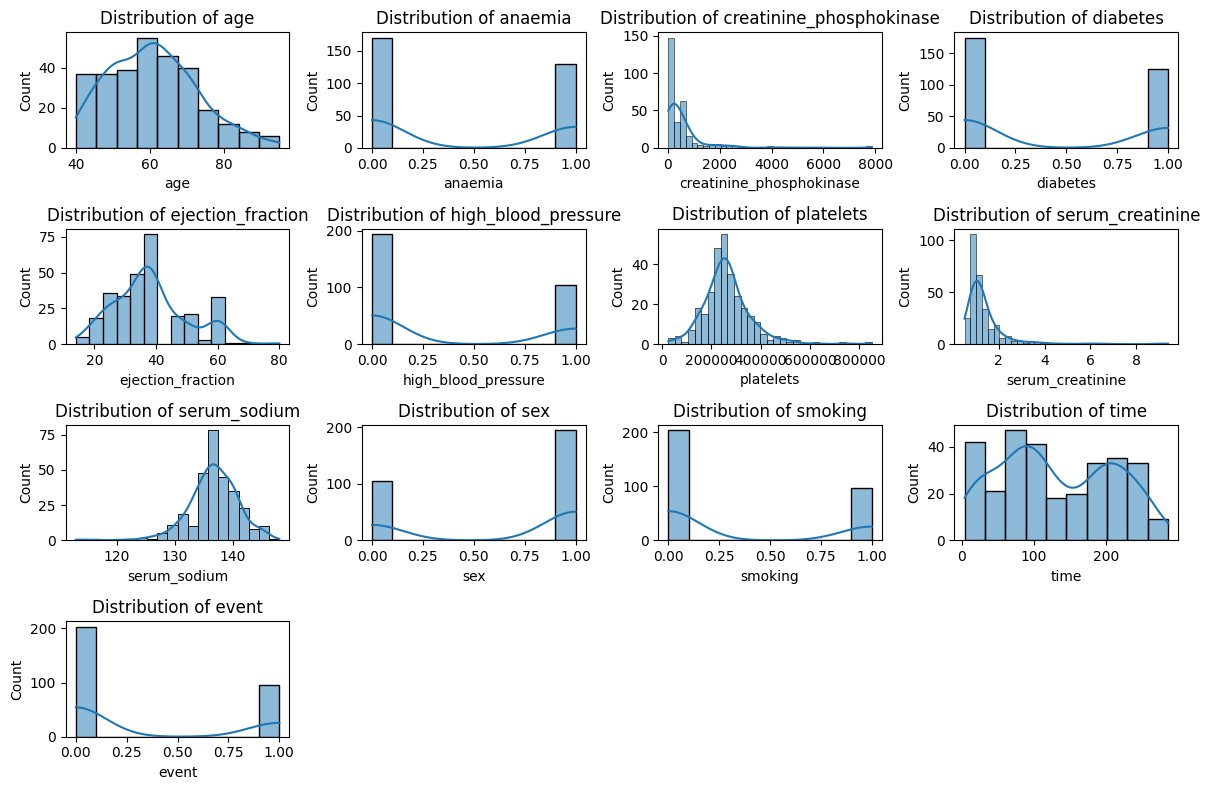

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns   

# Basic Feature Distributions
plt.figure(figsize=(12, 8))
for i, column in enumerate(df.columns[:], 1):  # Exclude 'time' and 'event'
    plt.subplot(4, 4, i)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()      

In [22]:
# Compare Survivors vs Non-Survivors
df.groupby('event').mean()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
event,,,,,,,,,,,,
0,58.761906,0.408867,540.054187,0.418719,40.26601,0.325123,266657.489901,1.184877,137.216749,0.650246,0.325123,158.339901
1,65.225698,0.479167,670.197917,0.416667,33.46875,0.406250,256381.044792,1.835833,135.375000,0.645833,0.312500,70.885417


In [23]:
# correlation with target variable
df.corr()['event'].sort_values(ascending=False)

event                       1.000000
serum_creatinine            0.294278
age                         0.254008
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
diabetes                   -0.001943
sex                        -0.004316
smoking                    -0.012623
platelets                  -0.049139
serum_sodium               -0.195204
ejection_fraction          -0.268603
time                       -0.526964
Name: event, dtype: float64

In [ ]:
# observation notes:
# - Exploratory analysis revealed that serum creatinine and age are positively associated with 
#   mortality risk, while ejection fraction and serum sodium show protective correlations. 
#   These findings align with established clinical literature on heart failure prognosis.

In [ ]:
#### what we achived till now:

# - Data cleaning
# - EDA
# - Survival dataset preparation
# - Event variable analysis
# - Correlation with predictors